score the seqeunces that MPNN made, we want to get the full probablily ditributino of the confindce per amino acid, not just the product of them which is what usually is returned
we also want to averge it over many decoding orders

In [ ]:

# the code is hardcoded for this stcutre for now, if chanaged make sure bash lines will aslo be reran
partial_struct_filename = "c6b6_partial_T25_34"
true_pdb_path = f"/data/leuven/368/vsc36835/thesis/hpc_scratch_link/Bence Files/For_bence/MPNN-for-c6-1/inputs/{partial_struct_filename}.pdb"  # Replace with your true PDB file
#predicted_dir = f"/data/leuven/368/vsc36835/thesis/hpc_scratch_link/Bence Files/c6b6/{partial_struct_filename}_esmfold"        # Folder containing predicted PDBs
mpnn_fa = f"/data/leuven/368/vsc36835/thesis/hpc_scratch_link/Bence Files/For_bence/MPNN-for-c6-1/seqs/{partial_struct_filename}.fa"

Create Json of c6b6_partial_T25_34 

the file was saved on its own folder at /data/leuven/368/vsc36835/thesis/MPNN_distribution_proeprties_check/bence files/c6b6_partial_T25_34_input_pdb/c6b6_partial_T25_34.pdb

In [ ]:
### just ran in a terminal
conda activate mpnn

python /data/leuven/368/vsc36835/thesis/MPNN_4/ProteinMPNN/helper_scripts/parse_multiple_chains.py --input_path="/data/leuven/368/vsc36835/thesis/MPNN_distribution_proeprties_check/bence files/c6b6_partial_T25_34_input_pdb/" --output_path="/data/leuven/368/vsc36835/thesis/MPNN_distribution_proeprties_check/bence files/c6b6_partial_T25_34_input_pdb/parsed_pdbs.jsonl"

/bin/bash: line 1: /data/leuven/368/vsc36835/thesis/MPNN_4/ProteinMPNN/helper_scripts/parse_multiple_chains.py: Permission denied


In [ ]:
python /data/leuven/368/vsc36835/thesis/MPNN_4/ProteinMPNN/protein_mpnn_run.py \
        --path_to_fasta "/data/leuven/368/vsc36835/thesis/MPNN_distribution_proeprties_check/bence files/test_fa.fa" \
        --jsonl_path "/data/leuven/368/vsc36835/thesis/MPNN_distribution_proeprties_check/bence files/c6b6_partial_T25_34_input_pdb/parsed_pdbs.jsonl" \
        --out_folder "/data/leuven/368/vsc36835/thesis/MPNN_distribution_proeprties_check/bence files/c6b6_partial_T25_34_input_pdb" \
        --num_seq_per_target 10 \
        --score_only 1 \
        --batch_size 1


### analyze

In [1]:
### add mpnn to path so i can load functio nfro mthere
import sys
from pathlib import Path

# 1. Get the absolute path to the directory containing 'utils.py'
# .parent.parent moves up from 'scripts/' to 'project/', then we go into 'tools/'
path_to_utils = "/data/leuven/368/vsc36835/thesis/MPNN_4/ProteinMPNN"

# 2. Add that path to sys.path
sys.path.append(str(path_to_utils))

# 3. Now you can import normally
from protein_mpnn_utils import _scores, _S_to_seq


In [ ]:
# load file
# this file contains scores of the SAME seqeunce just with diffrent deocding order for the scoreing
# the file is npz format and hold a few variables

import numpy as np
import torch
# npz_scores = np.load(r"/data/leuven/368/vsc36835/thesis/MPNN_distribution_proeprties_check/bence files/keep_25000_steps_c6b6_partial_T25_34_input_pdb/fullscores_c6b6_partial_T25_34_fa_index_0___T=0.2, sample=1, score=0.5935, global_score=0.5935, seq_recovery=0.1842.npz")
# npz_scores = np.load(r"/data/leuven/368/vsc36835/thesis/MPNN_distribution_proeprties_check/bence files/keep_25000_steps_c6b6_partial_T25_34_input_pdb/fullscores_c6b6_partial_T25_34_fa_index_1___T=0.2, sample=2, score=0.5769, global_score=0.5769, seq_recovery=0.2632.npz")
npz_scores = np.load(r"/data/leuven/368/vsc36835/thesis/MPNN_distribution_proeprties_check/bence files/keep_25000_steps_c6b6_partial_T25_34_input_pdb/fullscores_c6b6_partial_T25_34_fa_index_2___T=0.2, sample=3, score=0.6036, global_score=0.6036, seq_recovery=0.2632.npz")


In [ ]:
log_probs_list_stacked = torch.from_numpy(npz_scores["log_probs_list_stacked"])
probs_list_stacked = np.exp(npz_scores["log_probs_list_stacked"])
S = torch.from_numpy(npz_scores["S"])
mask = torch.from_numpy(npz_scores["mask"])
seq = npz_scores["seq"]
global_scores = npz_scores["global_scores"]

In [ ]:
# np.exp(npz_scores["log_probs_list_stacked"][0][0]).sum()

np.float32(1.0)

In [42]:
### sanity check
i = 5 # random i
global_scores[i].item() == _scores(S, log_probs_list_stacked[i], mask).item()

True

In [ ]:
probs_list_stacked[0][0].sum() #should be 1

np.float32(228.0)

In [32]:
# second sanity check 
_scores(S, log_probs_list_stacked.mean(axis=0), mask).item() == np.mean(global_scores)


np.True_

In [ ]:
probs_list_stacked.mean(axis=0).shape

(228, 21)

In [82]:
probs_list_stacked[:2,:,:].mean(axis=0)[4][10]

np.float32(0.026193699)

In [80]:
probs_list_stacked[:2,:,:][0][4][10]

np.float32(0.027342943)

In [81]:
probs_list_stacked[:2,:,:][1][4][10]

np.float32(0.025044454)

In [71]:
probs_list_stacked

array([[[0.21901739, 0.00478257, 0.02624091, ..., 0.0041423 ,
         0.00582053, 0.00411701],
        [0.00783068, 0.00622218, 0.00378748, ..., 0.00363918,
         0.0043289 , 0.00397168],
        [0.01592025, 0.00505096, 0.00652546, ..., 0.00405623,
         0.00744941, 0.00406927],
        ...,
        [0.00360363, 0.00376836, 0.00360027, ..., 0.00364873,
         0.00374833, 0.00361851],
        [0.00283519, 0.00331034, 0.00294726, ..., 0.00325547,
         0.00322394, 0.0033795 ],
        [0.03457402, 0.00597306, 0.31652927, ..., 0.00504002,
         0.00747151, 0.00440443]],

       [[0.10046949, 0.0054948 , 0.04053449, ..., 0.00491695,
         0.00914052, 0.00436484],
        [0.00469793, 0.00423789, 0.00353552, ..., 0.00325221,
         0.00395303, 0.00366638],
        [0.00301525, 0.00263094, 0.00416901, ..., 0.00321892,
         0.00474145, 0.00374761],
        ...,
        [0.00354351, 0.00368209, 0.00356148, ..., 0.00358397,
         0.00364751, 0.00357523],
        [0.0

In [ ]:
_scores(S, probs_list_stacked.mean(axis=0), mask).item()


AttributeError: 'numpy.ndarray' object has no attribute 'contiguous'

# The goal here is to try to check emrpticailly how many decoding orders to we need to try bedore the ditribution is converging. 

We start by having a running mean and then check the distnace between each of the steps to see the dimishign return of each additional sampe that we get.

In [46]:
import numpy as np

# Calculate the Running Totals (Cumulative Sum)
# This creates a (sample, length, AA) where index 'i' is the sum of slices 0 to i
cum_sum = np.cumsum(probs_list_stacked, axis=0)

# Create an empty container for the averages
running_means = np.zeros_like(cum_sum)

# Explicit 1D Loop for Division
# We visit each step 'i' and divide the lenx21 matrix by the scalar count 'i+1'
for i in range(len(probs_list_stacked)):
    count = i + 1
    # This is explicit Scalar Division: Matrix / Integer
    running_means[i] = cum_sum[i] / count


# plot the change between each step using  np.linalg.norm

In [53]:
# Calculate the 'Step-to-Step' change (Volatility)
# We start from index 1 because we need a 'previous' step to compare to
deltas = []
for i in range(1, len(running_means)):
    # This matrix subtraction is 1-to-1 (element-wise)
    diff_matrix = running_means[i] - running_means[i-1]
    
    # Calculate the total magnitude of change
    change_magnitude = np.linalg.norm(diff_matrix)
    deltas.append(change_magnitude)

# Convert to numpy array for easier plotting
deltas = np.array(deltas)

### linear scale

/tmp/ipykernel_1899564/3045024205.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


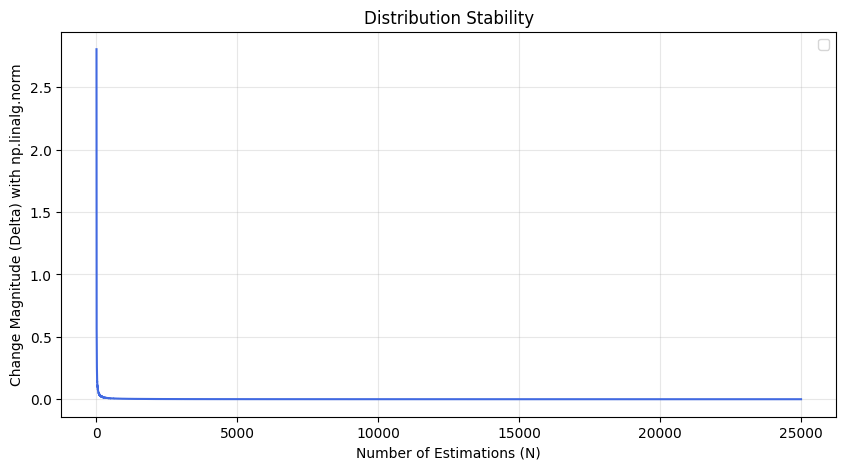

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(2, len(deltas)+2), deltas, color='royalblue', linewidth=1.5)


plt.xlabel("Number of Estimations (N)")
plt.ylabel("Change Magnitude (Delta) with np.linalg.norm")
plt.title("Distribution Stability")
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.legend()
plt.show()

/tmp/ipykernel_1899564/3440416003.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


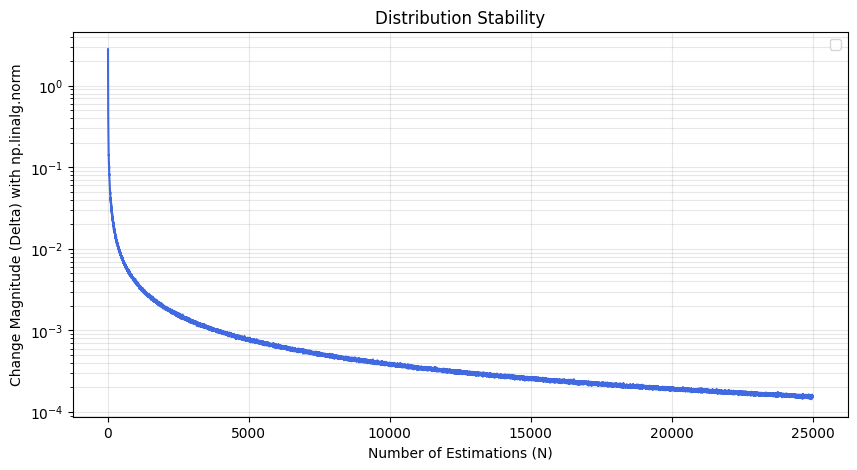

In [55]:
### log scale
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(2, len(deltas)+2), deltas, color='royalblue', linewidth=1.5)

# Use Log Scale to see the fine-grained stability at the end
plt.yscale('log')

plt.xlabel("Number of Estimations (N)")
plt.ylabel("Change Magnitude (Delta) with np.linalg.norm")
plt.title("Distribution Stability")
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.legend()
plt.show()

we calcualte teh jensenshannon isntead of KL divergence since kl divergence is non symetric and has an underlying assumption that one of the probality distribution si the true one. we wante to avoid it. currently not working sicne there is some instablity

In [ ]:
# import numpy as np
# from scipy.special import rel_entr
# import matplotlib.pyplot as plt

# def calculate_stable_jsd_history(running_means):
#     #  Cast the full array to float64 immediately
#     # This expands precision from 7 decimal places to ~16
#     data = running_means.astype(np.float64)
    
#     # Use a very small epsilon for ultra-fine precision
#     eps = 1e-15 
    
#     # Force strict normalization for every residue at every step 
#     data = (data + eps) / (data + eps).sum(axis=-1, keepdims=True)
    
#     jsd_history = []
    
#     for i in range(1, len(data)):
#         p = data[i]     # Shape (len, 21)
#         q = data[i-1]   # Shape (len, 21)
#         m = 0.5 * (p + q)
        
#         # Calculate KL(P||M) and KL(Q||M) using Relative Entropy
#         # We sum across the 21 amino acids (axis 1)
#         kl_pm = np.sum(rel_entr(p, m), axis=1)
#         kl_qm = np.sum(rel_entr(q, m), axis=1)
        
#         # 5. Jensen-Shannon Divergence per residue
#         jsd_per_residue = 0.5 * (kl_pm + kl_qm)
        
#         # Total System Divergence for the 200-residue protein
#         jsd_history.append(np.sum(jsd_per_residue))
        
#     return np.array(jsd_history)

# # Execute the calculation
# jsd_values = calculate_stable_jsd_history(running_means)

In [ ]:
# from scipy.spatial.distance import jensenshannon
# import numpy as np

# jsd_history = []


# eps = 1e-12
# running_means = running_means + eps / (running_means + eps).sum(axis=-1, keepdims=True)

# for i in range(1, len(running_means)):
#     # Get the JS Distance for all residues at once
#     js_distances = jensenshannon(running_means[i], running_means[i-1], axis=1)
    
#     # Square them to get Divergences and sum for the "Total System" change
#     # This gives you one number representing the whole protein's stability
#     total_step_jsd = np.sum(np.square(js_distances))
    
#     jsd_history.append(total_step_jsd)

# jsd_history = np.array(jsd_history)

<function scipy.stats._entropy.entropy(pk: collections.abc.Buffer | numpy._typing._array_like._SupportsArray[numpy.dtype[Any]] | numpy._typing._nested_sequence._NestedSequence[numpy._typing._array_like._SupportsArray[numpy.dtype[Any]]] | complex | bytes | str | numpy._typing._nested_sequence._NestedSequence[complex | bytes | str], qk: collections.abc.Buffer | numpy._typing._array_like._SupportsArray[numpy.dtype[Any]] | numpy._typing._nested_sequence._NestedSequence[numpy._typing._array_like._SupportsArray[numpy.dtype[Any]]] | complex | bytes | str | numpy._typing._nested_sequence._NestedSequence[complex | bytes | str] | None = None, base: float | None = None, axis: int = 0, *, nan_policy='propagate', keepdims=False) -> numpy.number | numpy.ndarray>

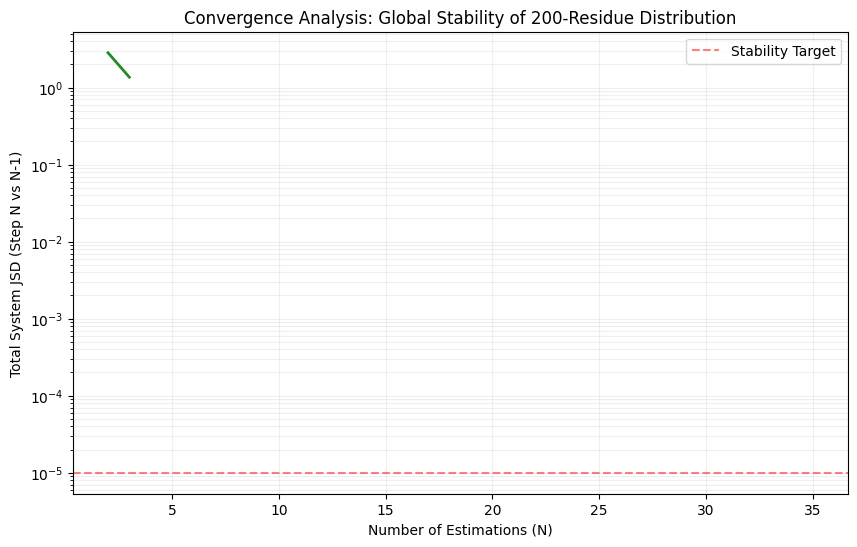

In [ ]:
# import scipy
# scipy.stats.entropy
# # 2. Plot the results
# plt.figure(figsize=(10, 6))
# plt.plot(range(2, 1001), jsd_history, color='forestgreen', linewidth=2)

# plt.yscale('log') # Better for seeing convergence
# plt.xlabel("Number of Estimations (N)")
# plt.ylabel("Total System JSD (Step N vs N-1)")
# plt.title("Convergence Analysis: Global Stability of 200-Residue Distribution")
# plt.grid(True, which="both", ls="-", alpha=0.2)

# # Optional: Add a threshold line to mark "Stability"
# plt.axhline(y=1e-5, color='red', linestyle='--', alpha=0.5, label='Stability Target')
# plt.legend()

# plt.show()

Kl divergence

In [56]:
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

def get_total_system_kl(current_running_mean, previous_running_mean):
    # 1. Cast to float64 to ensure 15+ decimal places of precision
    # This prevents the 0.9999999 vs 1.0 rounding errors
    p = current_running_mean.astype(np.float64)
    q = previous_running_mean.astype(np.float64)
    
    # 2. Calculate KL divergence for each of the 200 residues
    # axis=1 targets the 21 amino acid probabilities
    kl_per_residue = entropy(p, q, axis=1)
    
    # 3. Sum all 200 KL values to get the total system stability
    return np.sum(kl_per_residue)

# --- Main Loop ---
kl_history = []
for i in range(1, len(running_means)):
    total_kl = get_total_system_kl(running_means[i], running_means[i-1])
    kl_history.append(total_kl)

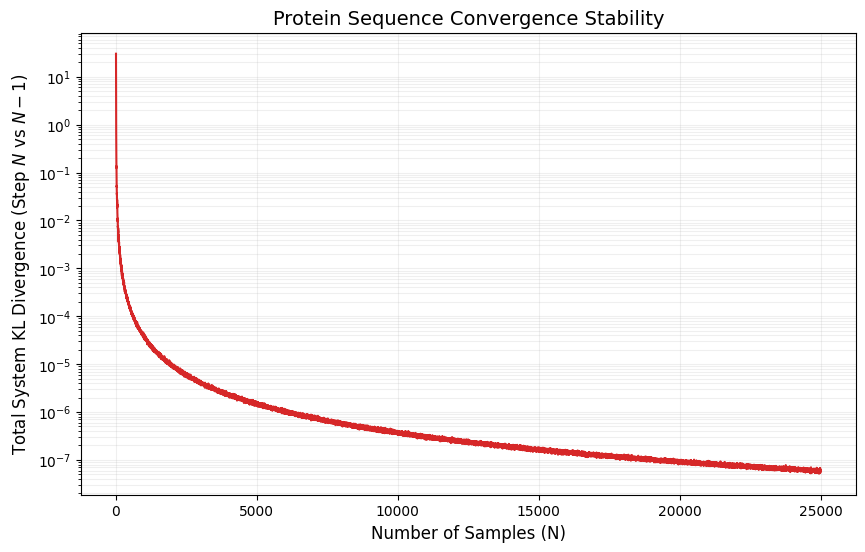

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, len(kl_history)+2), kl_history, color='tab:red', linewidth=1.5)

# Log scale is essential to see stability at small values
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.xlabel('Number of Samples (N)', fontsize=12)
plt.ylabel('Total System KL Divergence (Step $N$ vs $N-1$)', fontsize=12)
plt.title('Protein Sequence Convergence Stability', fontsize=14)

plt.show()